## Step 1: Understand Your Data

## Load and preview the dataset.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df=pd.read_csv(r"D:\stat\US_Customer_Insights_Dataset.csv")

In [36]:
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


## Check data types, unique values, and presence of nulls.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [38]:
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

## Understand which variables are categorical and which are numerical.

In [39]:
categorical_cols=df.select_dtypes(include='object')
categorical_cols

,CustomerID,Name,State,Education,Gender,Married,JoinDate,TransactionDate
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,Yes,9/19/21,9/2/24
1,CUST10695,Jennifer Burton,Washington,Master,Male,Yes,4/5/24,6/2/24
2,CUST10297,Michelle Rogers,Arizona,Master,Female,Yes,7/24/24,2/28/25
3,CUST10103,Brooke Hendricks,Texas,Master,Male,Yes,8/12/23,3/29/25
4,CUST10219,Karen Johns,Texas,High School,Female,Yes,12/6/21,7/24/22
...,...,...,...,...,...,...,...,...
10670,CUST10833,Steven Burns,Georgia,PhD,Female,No,8/24/23,2/29/24
10671,CUST10620,Jesse Pratt,Texas,Master,Male,No,4/13/23,12/31/24
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,Yes,7/3/22,9/21/23
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,No,9/19/23,12/29/23


In [40]:
numerical_cols=df.select_dtypes(include='number')
numerical_cols

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
0,47,1,1281.74,332
1,72,0,429.46,424
2,40,2,510.34,153
3,27,0,396.47,124
4,28,1,139.68,1103
...,...,...,...,...
10670,60,1,341.28,518
10671,64,0,468.04,212
10672,31,0,259.94,679
10673,31,0,494.17,580


## Step 2: Mean, median, std dev for Age, MonthlySpend, DaysSinceLastInteraction

In [41]:
print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].std())

49.47456674473068
49.0
18.22136549414863


Insight: The Age variable appears to be approximately symmetric/normally distributed since the mean(4.9.47)and median(49) are nearly identic.The average customer age is around 49 years,with a moderate varion of 18.22 years.

In [42]:
print(df['MonthlySpend'].mean())
print(df['MonthlySpend'].median())
print(df['MonthlySpend'].std())

331.61031475409834
282.11
225.7992527582449


Observation: For MonthlySpend the Mean>Median

Insight: MonthlySpend is positively skewed because the mean (331.61) is greater than the median (282.11). This suggests that a small group of high-spending customers is increasing the average spending amount. The high standard deviation (225.80) indicates considerable variability in customer spending.

In [43]:
print(df['DaysSinceLastInteraction'].mean())
print(df['DaysSinceLastInteraction'].median())
print(df['DaysSinceLastInteraction'].std())

538.4698829039812
445.0
398.7667466311463


Observation:For DaysSinceLastInteraction the Mean>Median

Insight:DaysSinceLastInteraction is positively skewed because the mean (538.47) is greater than the median (445). This indicates that while many customers have interacted with the company relatively recently, a smaller group of customers has not interacted for a much longer period. The high standard deviation (398.77) shows that there is significant variation in customer engagement levels.

Business Insight:

The customer base has an average age of approximately 49 years and shows a fairly balanced age distribution. Customer spending behavior varies considerably, with a small segment of customers contributing significantly higher spending amounts than the majority. Customer engagement also differs widely, as some customers have not interacted with the company for a long time. These inactive customers can be targeted through retention campaigns, personalized offers, or re-engagement strategies to improve customer activity and overall business performance.

## Mode for categorical variables: Gender, Education, Married

In [44]:
print(df['Gender'].mode())

0    Male
Name: Gender, dtype: object


Statistical Insight:
The mode of the Gender column is Male, indicating that male customers represent the most frequently occurring gender category in the dataset.

Business Insight: Since male customers form the largest customer segment, the company may consider analyzing their purchasing behavior and preferences to design targeted marketing campaigns and improve customer engagement.

In [45]:
print(df['Education'].mode())

0    Master
Name: Education, dtype: object


Statistical Insight:
The mode of the Education column is Master, which indicates that customers with a Master's degree are the most common educational group in the dataset.

Business Insight:
The customer base appears to be highly educated, with Master's degree holders forming the largest segment. This may influence product positioning, communication strategies, and the design of premium offerings tailored to professionally qualified customers.

In [46]:
print(df['Married'].mode())

0    No
Name: Married, dtype: object


Statistical Insight:
The mode of the Married column is No, indicating that unmarried customers constitute the largest category in the dataset.

Business Insight:
Since unmarried customers represent the largest customer group, the company can explore products, services, and promotional campaigns that align with the preferences and lifestyle needs of single individuals

Overall Categorical Variables Insight
Business Insight:
The most common customer profile in the dataset is a male customer with a Master's degree who is unmarried. Understanding the preferences and behavior of this dominant customer segment can help the company develop more effective marketing, retention, and customer engagement strategies.

## Step 3: Data Visualization

#  Plot histograms and boxplots for Age, MonthlySpend

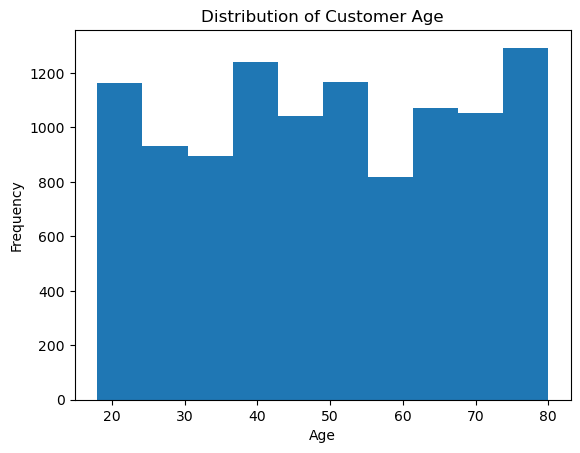

In [47]:
plt.hist(df['Age'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Age')
plt.show()

Statistical Insight
The age distribution appears relatively uniform across the age range of 18 to 80 years, with no extreme concentration in any particular age group. Most age intervals contain a similar number of customers, indicating a well-balanced dataset. There is no strong skewness toward younger or older customers, suggesting that customers from different age groups are represented fairly evenly.

Business Insight
Since customers are distributed across a wide range of ages, the business serves a diverse customer base rather than relying on a single age segment. This suggests that marketing campaigns, products, and services should be designed to appeal to multiple age groups. Age-specific promotions may still be effective, but the company should avoid focusing exclusively on either younger or older customers because both groups contribute substantially to the customer population.

{'whiskers': [<matplotlib.lines.Line2D at 0x182473a56d0>,
 'caps': [<matplotlib.lines.Line2D at 0x182473a5950>,
 'boxes': [<matplotlib.lines.Line2D at 0x182473a5590>],
 'medians': [<matplotlib.lines.Line2D at 0x182473a5bd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x182473a5d10>],
 'means': []}

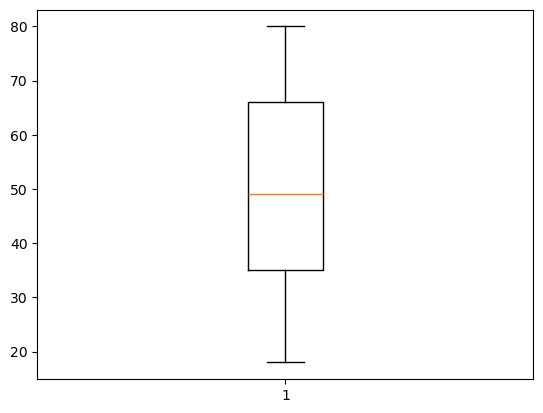

In [48]:
plt.boxplot(df['Age'])

observation:The age distribution is symmetric around 49, showing no skew and a wide spread across younger and older groups.

Statistical Insight
The box plot shows that the age distribution is relatively symmetric around a median age of approximately 49 years. The middle 50% of customers fall between roughly 34 and 65 years, indicating a wide age spread. No significant outliers are present, suggesting that the dataset contains age values within a consistent and expected range.

Business Insight
The customer base consists of a broad mix of younger, middle-aged, and older individuals, with the typical customer being around 49 years old. Since there are no extreme age concentrations or unusual age groups, the business has the opportunity to serve multiple generations. Marketing strategies and product offerings should therefore be designed to appeal to diverse age segments rather than focusing on a narrow age group.

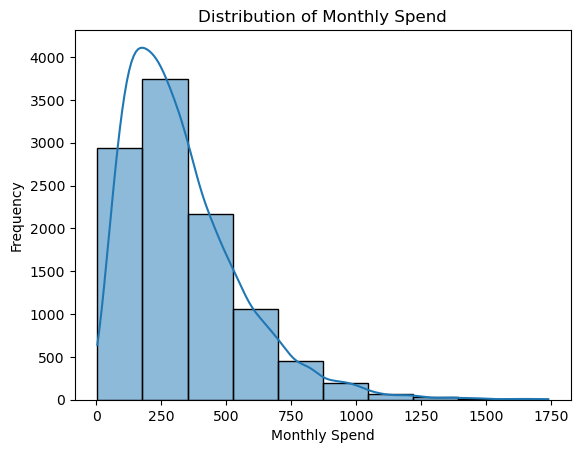

In [49]:
sns.histplot(df['MonthlySpend'],bins=10,kde=True)
plt.title('Distribution of Monthly Spend')
plt.xlabel('Monthly Spend')
plt.ylabel('Frequency')

plt.show()

Statistical Insight
The distribution of Monthly Spend is positively skewed (right-skewed), as most observations are concentrated at lower spending values while a few observations extend toward higher spending values. This is supported by the mean (331.61) being greater than the median (282.11). The long right tail indicates the presence of high-spending customers.

Business Insight
Most customers have low to moderate monthly spending, while a small group of customers spends significantly more than the average. These high-value customers are important contributors to revenue and can be targeted with loyalty programs, premium services, and personalized offers to improve customer retention and profitability.

{'whiskers': [<matplotlib.lines.Line2D at 0x18246fbbed0>,
 'caps': [<matplotlib.lines.Line2D at 0x18246fbbc50>,
 'boxes': [<matplotlib.lines.Line2D at 0x182425b20d0>],
 'medians': [<matplotlib.lines.Line2D at 0x18246fbb890>],
 'fliers': [<matplotlib.lines.Line2D at 0x18246fbb610>],
 'means': []}

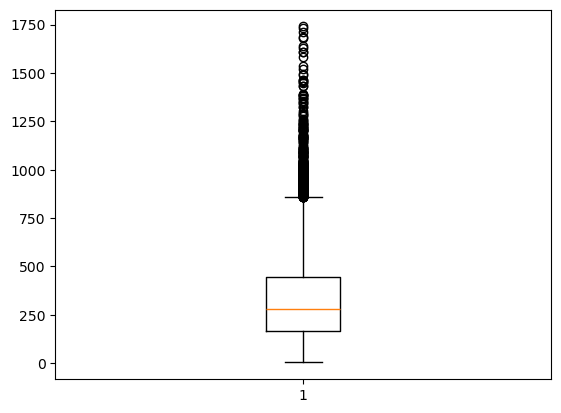

In [50]:
plt.boxplot(df['MonthlySpend'])

Statistical Insight for the Box Plot
The box plot of MonthlySpend reveals the presence of numerous upper-end outliers. These outliers indicate that while most customers have moderate spending levels, a smaller group of customers spends substantially more than the typical customer. The concentration of outliers above the upper whisker further confirms that the distribution is positively skewed.

Business Insight for the Box Plot
The presence of many high-spending outliers suggests the existence of a valuable customer segment that contributes significantly to overall revenue. These customers can be targeted with loyalty programs, premium memberships, personalized recommendations, and exclusive offers to enhance retention and maximize business value.

##  Create a bar chart for Gender, Education, State

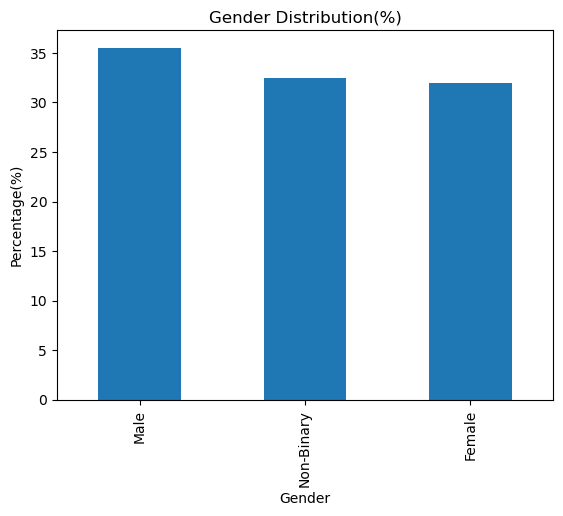

In [51]:
(df['Gender'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title('Gender Distribution(%)')
plt.xlabel('Gender')
plt.ylabel('Percentage(%)')
plt.show()

EDA Report Statement:
The gender distribution is fairly balanced across all categories. Male customers account for the highest proportion of the dataset (approximately 36%), while Female and Non-Binary customers each contribute around 33%. The small differences indicate that the dataset has good representation across all gender groups

Business Report Statement
The customer base demonstrates strong gender diversity, with all categories contributing significantly to the overall population. This balanced distribution supports inclusive marketing and product strategies. Although Male customers form the largest segment, the difference is modest, indicating that business growth opportunities exist across all gender groups rather than within a single dominant segment.

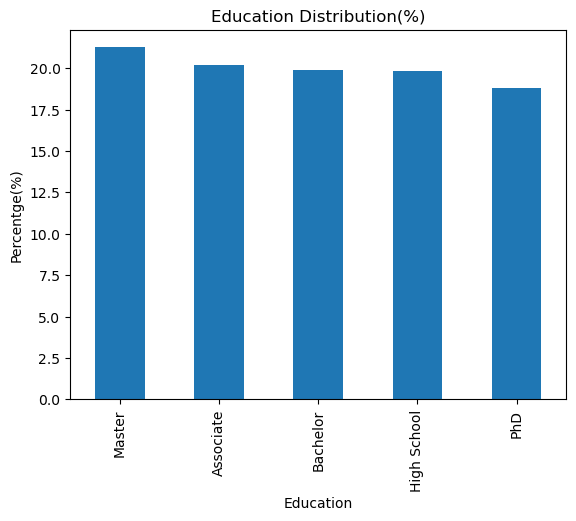

In [52]:
(df['Education'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title('Education Distribution(%)')
plt.xlabel('Education')
plt.ylabel('Percentge(%)')
plt.show()

Observation: "The distribution is fairly balanced. Customers with a Master's degree form the largest segment, while PhD holders form the smallest. Associate, Bachelor's, and High School categories have nearly equal representation. This suggests that the customer base is diverse in terms of education level, and no single educational group dominates the dataset."

Business Report Statement: The education distribution is relatively balanced across all categories, indicating that the customer base is diverse in terms of educational background. Customers with a Master's degree represent the largest segment of the population (approximately 21%), while PhD holders constitute the smallest segment (approximately 19%). Associate, Bachelor's, and High School education levels show nearly equal representation, suggesting no significant educational disparity among customers. From a business perspective, the balanced distribution indicates that products and services appeal to individuals across various educational backgrounds. Therefore, marketing, communication, and customer engagement strategies should be designed to cater to a broad audience rather than focusing on a single educational segment.

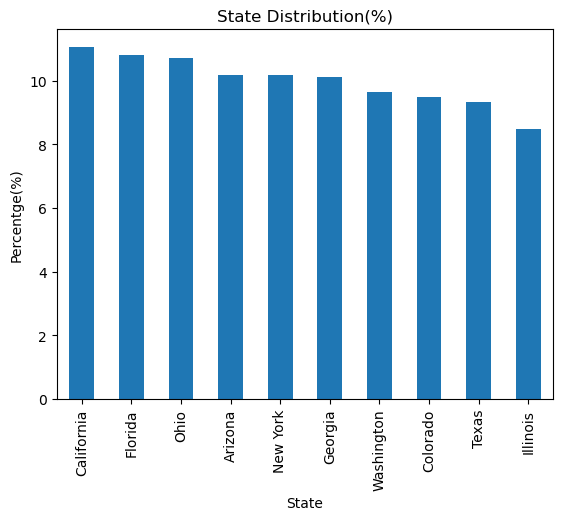

In [53]:
(df['State'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title('State Distribution(%)')
plt.xlabel('State')
plt.ylabel('Percentge(%)')
plt.show()

Business Report Statement: The customer distribution across states is relatively balanced, with California having the highest representation and Illinois the lowest. However, the differences between states are minimal, indicating that customers are evenly distributed across the regions represented in the dataset. This suggests that the business is not heavily dependent on a single state and is balanced geographic distribution reduces regional concentration risk and suggests that marketing and operational efforts can be distributed relatively evenly across states

##  Scatterplot: Age vs MonthlySpend

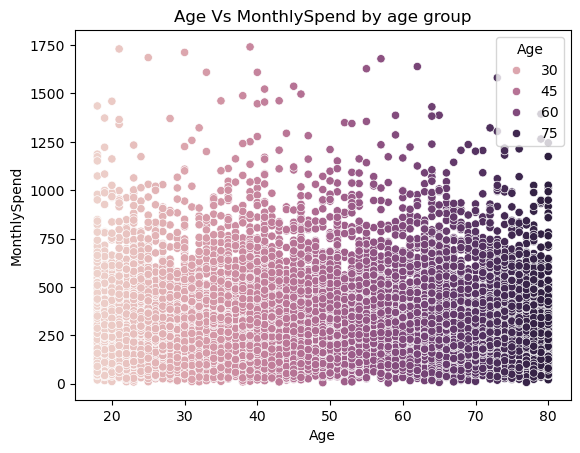

In [54]:
sns.scatterplot(data=df,x='Age',y='MonthlySpend',hue='Age')
plt.title('Age Vs MonthlySpend by age group')
plt.xlabel('Age')
plt.ylabel('MonthlySpend')
plt.show()

Statistical Insight:The scatter plot shows no strong correlation between Age and MonthlySpend, as customers across different age groups exhibit a wide range of spending behaviors. Monthly spending is highly variable within each age group, and several high-spending outliers are present. This suggests that age alone is not a reliable predictor of customer spending and that other factors may have a greater influence on purchasing behavior

Business Insight
Since spending patterns remain similar across different age groups, age-based segmentation may not be the most effective strategy for understanding customer spending behavior. The organization should explore additional factors such as income, occupation, lifestyle, or purchasing preferences to identify stronger drivers of spending. Furthermore, the presence of high-spending customers presents an opportunity for targeted loyalty programs, personalized offers, and retention strategies to maximize revenue and customer value.

## KDE: Spending behavior by education level or marital status

<Axes: xlabel='MonthlySpend', ylabel='Density'>

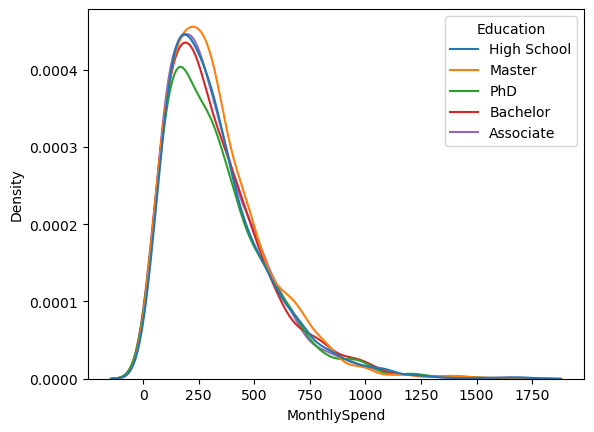

In [55]:
sns.kdeplot(data=df,x='MonthlySpend',hue='Education')

Statistical Insight
The KDE curves show that spending patterns are broadly similar across education levels, but individuals with a Master's degree exhibit a slightly higher concentration of spending in the moderate-to-high spending range. In contrast, individuals with a PhD show a lower spending density and tend to spend less on average. The distributions are highly overlapping, indicating that education level has only a moderate influence on monthly spending behavior.

Business Insight
Customers with a Master's degree appear to be the most valuable spending segment and may respond well to premium products, loyalty programs, and targeted marketing campaigns. Customers with a PhD tend to have lower spending levels, suggesting that cost-conscious offers, discounts, or value-based product bundles may be more effective for this group.

<Axes: xlabel='MonthlySpend', ylabel='Density'>

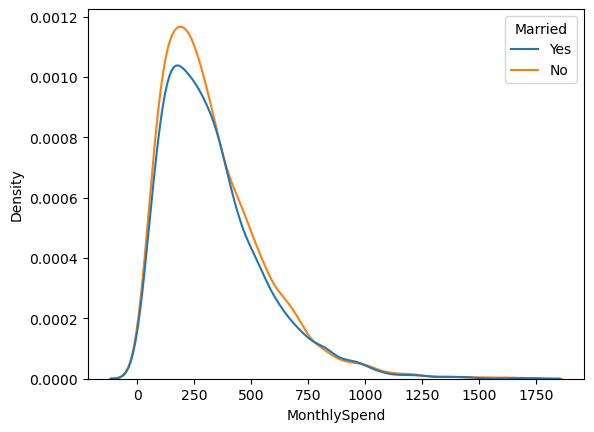

In [56]:
sns.kdeplot(data=df,x='MonthlySpend',hue='Married')

Statistical Insight
The spending distributions of married and unmarried customers are highly similar, indicating that marital status has a limited effect on spending behavior. However, the unmarried group exhibits a slightly higher density around the primary spending range, suggesting that unmarried customers tend to spend marginally more than married customers.

Business Insight
Unmarried customers show a slightly higher spending tendency compared to married customers. Businesses may consider targeting unmarried customers with premium products, lifestyle offerings, and personalized promotions. However, because the difference between the two groups is relatively small, marital status alone should not be used as the primary basis for customer segmentation.

## Step 4: Bivariate Analysis

##  Correlation matrix (numeric variables)


In [57]:
df.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='object')

In [58]:
df[['NumPets','MonthlySpend','DaysSinceLastInteraction','Age']].corr()

,NumPets,MonthlySpend,DaysSinceLastInteraction,Age
NumPets,1.000000,0.020647,-0.055227,-0.023035
MonthlySpend,0.020647,1.000000,0.006081,-0.012323
DaysSinceLastInteraction,-0.055227,0.006081,1.000000,-0.003970
Age,-0.023035,-0.012323,-0.003970,1.000000


<Axes: >

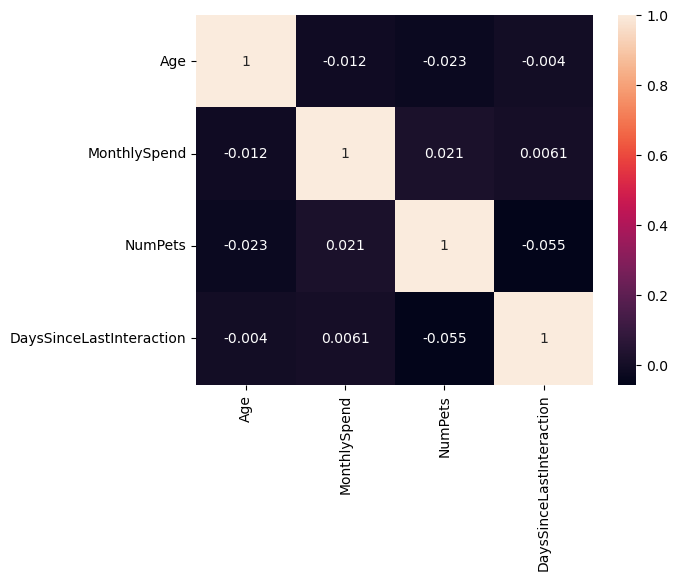

In [59]:
sns.heatmap(df[['Age','MonthlySpend','NumPets','DaysSinceLastInteraction']].corr(),annot=True)

Statistical Insight:
The correlation analysis indicates that all numerical variables (Age, MonthlySpend, NumPets, and DaysSinceLastInteraction) have correlation coefficients close to zero. This suggests that there is no significant linear relationship among these variables, and they are largely independent of one another.

Business Insight:
Customer spending behavior does not appear to be strongly influenced by age, number of pets, or recency of interaction. Since no meaningful relationships were observed among the numerical variables, additional factors such as gender, education, marital status, or state may provide better insights into customer behavior.

Conclusion:
The correlation matrix reveals weak correlations across all numerical variables, indicating that these factors alone are insufficient to explain customer spending patterns. Further analysis of categorical variables is recommended to identify more actionable business insights

# Crosstab of Gender vs Married

In [60]:
pd.crosstab(df['Gender'],df['Married'])

Married,No,Yes
Gender,,
Female,1797,1616
Male,1892,1899
Non-Binary,1894,1577


In [61]:
pd.crosstab(df['Gender'],df['Married'],normalize='index')*100

Married,No,Yes
Gender,,
Female,52.651626,47.348374
Male,49.907676,50.092324
Non-Binary,54.566407,45.433593


Statistical Insight

The percentage distribution of marital status across gender groups shows a relatively balanced pattern. Among female customers, 52.65% are unmarried and 47.35% are married. Male customers exhibit an almost equal distribution, with 49.91% unmarried and 50.09% married. Among non-binary customers, 54.57% are unmarried and 45.43% are married. Overall, the differences between married and unmarried customers within each gender category are small, indicating no strong association between gender and marital status.

Business Insight

The customer base is well balanced across gender and marital status categories, suggesting that marital status is distributed similarly among different gender groups. Male customers show the most even split between married and unmarried individuals, while female and non-binary customers have a slightly higher proportion of unmarried customers. Since no gender group exhibits a dominant marital status pattern, businesses may find limited value in segmenting customers solely based on gender and marital status. Additional factors such as spending behavior, education level, or geographic location may provide more meaningful customer insights.

Conclusion

The cross-tabulation analysis indicates a fairly uniform distribution of marital status across gender categories. No significant disparities are observed, suggesting that gender is not a strong indicator of marital status within this customer dataset. Further analysis involving customer spending and engagement metrics is recommended to identify more actionable business patterns.

# Grouped stats: average MonthlySpend by State, Education, Gender

In [62]:
df.groupby('State')['MonthlySpend'].mean()

State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64

Statistical Insights :
Arizona has the highest average monthly spend (341.49).
Ohio (340.19) and California (339.18) are the next highest spending states.
Texas has the lowest average monthly spend (319.51).
The difference between the highest and lowest average spend is approximately 22 units.
Spending levels vary across states, indicating geographical differences in customer behavior.
EDA Statistical Report

Business Insights :
Arizona, Ohio, and California contribute the highest average revenue.
Texas customers spend less on average.
Geographic location may influence purchasing behavior.
Regional marketing strategies could improve business performance.

Conclusion :
Customer spending varies across states, with Arizona showing the highest average monthly spend and Texas the lowest. This suggests that geographic factors may influence spending behavior, making state-level segmentation a potential opportunity for targeted marketing initiatives.

In [63]:
df.groupby('Education')['MonthlySpend'].mean()

Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64

Statistical Insights:
 Customers with a Master's degree have the highest average monthly spend (334.25).
 Customers with an Associate degree have the lowest average monthly spend (327.88).
 The difference between the highest and lowest average spend is approximately 6.37 units.
 Spending patterns are relatively similar across all education levels.
 Education level shows only minor variation in average monthly spending.

Business Insights:
 Customers across different education levels exhibit comparable spending behavior.
 Master's degree holders spend slightly more on average than other groups.
 The small differences in spending suggest that education is not a major driver of customer expenditure.
 Marketing strategies based solely on education level may have limited effectiveness.

Conclusion:
The analysis indicates that average monthly spending remains fairly consistent across education levels, with only minor differences observed between groups. This suggests that educational attainment has a limited influence on customer spending behavior and may not be a strong segmentation variable for targeted business strategies.

In [64]:
df.groupby('Gender')['MonthlySpend'].mean()

Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64

Statistical Insights:
 Male customers have the highest average monthly spend (333.17).
 Female customers have an average monthly spend of 331.36.
 Non-binary customers have the lowest average monthly spend (330.15).
 The difference between the highest and lowest spending groups is approximately 3 units.
 Spending behavior is highly consistent across all gender categories.


Business Insights:
 All gender groups contribute similar levels of average monthly revenue.
 No gender category demonstrates substantially higher spending behavior.
 Gender appears to have minimal impact on customer spending patterns.
 Customer segmentation based solely on gender is unlikely to generate significant business advantages.


Conclusion:
The average monthly spending across gender groups is nearly identical, indicating that gender has little influence on customer purchasing behavior. As a result, businesses may benefit more from focusing on other customer characteristics, such as geographic location or engagement patterns, rather than gender-based segmentation.

In [65]:
df.groupby(['State','Education','Gender'])['MonthlySpend'].mean().sort_values().reset_index()

,State,Education,Gender,MonthlySpend
0,Georgia,High School,Male,235.443200
1,Georgia,PhD,Non-Binary,279.401846
2,New York,Bachelor,Non-Binary,283.990545
3,Texas,High School,Non-Binary,283.999277
4,Washington,Associate,Non-Binary,284.959362
...,...,...,...,...
145,Ohio,High School,Male,375.850291
146,Illinois,Bachelor,Female,377.823051
147,Ohio,Master,Non-Binary,377.908529
148,New York,Master,Non-Binary,391.405161


Insights:
Georgia High-School males spend the least.
Non-Binary groups in New York and Texas spend moderatey.
Georgia	PhD	Male spend  the most.

## Step 5: Formulate Hypotheses
Business Purpose: Turn business questions into statistical tests.
Business Question Statistical Test
Do males and females spend differently? Independent t-test
Does education level impact average monthly
spend? One-way ANOVA
Is marital status related to the number of
pets owned? [Only for DS Students] Chi-square test
Are older people less active? Correlation (Age vs
DaysSinceLastInteraction)
Does state-wise spend vary significantly? ANOVA

## Do males and females spend differently? Independent t-test

Null Hypothesis:Mean Spend of male is equal to mean spend of females  
Alternate Hypothesis:Both the means are not equal

In [66]:
male=df.loc[df['Gender']=='Male','MonthlySpend']
male

1        429.46
3        396.47
7        175.81
8        320.48
11       912.80
          ...  
10654    180.31
10663    263.93
10667    839.65
10668    171.54
10671    468.04
Name: MonthlySpend, Length: 3791, dtype: float64

In [67]:
female=df.loc[df['Gender']=='Female','MonthlySpend']
female

2        510.34
4        139.68
5        423.45
9        151.49
14       103.30
          ...  
10662     90.95
10664    266.37
10666    483.33
10670    341.28
10673    494.17
Name: MonthlySpend, Length: 3413, dtype: float64

In [68]:
male=df.loc[df['Gender']=='Male','MonthlySpend']
female=df.loc[df['Gender']=='Female','MonthlySpend']

In [69]:
from scipy.stats import ttest_ind
t_stat,p_value=ttest_ind(male,female,equal_var=False)
print("p_value is",p_value)

p_value is 0.7345215220030699


Business Purpose: p_value is greater  than the value of alpha. therefore,we fail to reject the null hypothesis 

Statistical Insight
An Independent Samples t-test was conducted to compare the average monthly spending of male and female customers. The test produced a p-value of 0.7345, which is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis and conclude that there is no statistically significant difference in monthly spending between male and female customers.

Business Insight
Customer spending behavior appears to be similar across genders. Gender is not a significant driver of monthly spending in this dataset. As a result, designing separate promotional campaigns, pricing strategies, or discounts based solely on gender is unlikely to produce meaningful business benefits. The company should focus on other customer characteristics that may have a stronger impact on spending patterns.

EDA Insight:
The dataset contains 3,791 male and 3,413 female customers. Monthly spending patterns appear similar across both groups, with no clear visual indication of a major difference. Therefore, an Independent Samples t-test was conducted to determine whether the observed difference in spending is statistically significant.

## Does education level impact average monthlyspend?

Null Hypothesis: The Mean MonthlySpend is equal across all education levels.  
Alternate Hypothesis:At least one education level has a different mean MonthlySpend.

In [70]:
phd=df.loc[df['Education']=='PhD','MonthlySpend']
master=df.loc[df['Education']=='Master','MonthlySpend']
bachelor=df.loc[df['Education']=='Bachelor','MonthlySpend']
associate=df.loc[df['Education']=='Associate','MonthlySpend']
highschool=df.loc[df['Education']=='High School','MonthlySpend']

In [71]:
#one-way ANOVA is the Appropriate
from scipy.stats import f_oneway
f_stat,p_value=f_oneway(phd,master,bachelor,associate,highschool)
print(p_value)

0.922359467759936


insight: Since the value of p is greater then alpha,therefor we fail to reject the null hypothesis.

Statistical Insight
A One-Way ANOVA test was conducted to compare average MonthlySpend across five education levels. The test returned a p-value of 0.9224, which is significantly greater than the significance level of 0.05. Therefore, the null hypothesis was not rejected, indicating that there is no statistically significant difference in average monthly spending among the education groups.

Business Insight Education level does not significantly influence customer spending behavior. Customers with High School, Associate, Bachelor, Master, and PhD qualifications spend at comparable levels on average. Therefore, education is not an effective variable for customer segmentation, personalized promotions, or spending prediction. The business should focus on other customer attributes such as age, state, engagement level, or recency of interaction to identify meaningful differences in spending behavior.

EDA Insight
Customers belonging to High School, Associate, Bachelor, Master, and PhD education groups exhibit similar monthly spending patterns. Initial exploration did not indicate any substantial difference in spending behavior among the education categories, leading to further validation through ANOVA testing.

##  Is marital status related to the number ofpets owned?

Null Hypothesis : Marital Status and Pets Owned is independent  
Alternate Hypothesis:Marital Status and pets Owned is dependent

In [72]:
table=pd.crosstab(df['Married'],df['NumPets'])
table

NumPets,0,1,2,3,4
Married,,,,,
No,1839,1435,1504,509,296
Yes,1205,1770,1242,598,277


In [73]:
from scipy.stats import chi2_contingency
chi2,p_value,dof,expected=chi2_contingency(table)
print(p_value)

2.3957232932397494e-37


insight: p_value is less than alpha,therefore we fail to reject the null hypothesis.

Statistical Insight:

The Chi-Square test returned a very small p-value (2.396 × 10⁻³⁷), which is much lower than 0.05. Therefore, the null hypothesis is rejected. This suggests that marital status and the number of pets owned are not independent of each other. The distribution of pet ownership differs between married and unmarried individuals.

Business Insight:

The data indicates that pet ownership behavior varies with marital status. Married individuals appear more likely to own at least one pet, while unmarried individuals are more commonly found in the no-pet category. This suggests that family structure or household composition may influence pet ownership decisions. Businesses selling pet products or services could use marital status as one of the factors for customer segmentation and targeted marketing.

EDA Insight:

From the contingency table, the biggest difference can be seen in the categories of 0 pets and 1 pet. A larger number of unmarried individuals have no pets, whereas married individuals are more concentrated in the one-pet category. This visible pattern in the data supports the statistical result that marital status and pet ownership are related.

##  Are older people less active? Correlation (Age vsDaysSinceLastInteraction)

Null Hypothesis : There is no relationship between age and days since last interaction 
Alternate Hypothesis: opposite of above 

In [74]:
from scipy.stats import pearsonr
corr,p_value =pearsonr(df['Age'],df['DaysSinceLastInteraction'])
print('Correlation Coefficient',corr)
print('p_value',p_value)

Correlation Coefficient -0.003970230104955049
p_value 0.6816905437300954


p_value is greater than alpha,therefor we fail to reject the null hypothesis

Statistical Insight:
Pearson correlation analysis revealed no statistically significant relationship between Age and DaysSinceLastInteraction (p = 0.682 > 0.05). This indicates that customer age does not have a significant impact on the number of days since the last interaction. Therefore, we fail to reject the null hypothesis and conclude that customer engagement is independent of age in this dataset.

Business Insight:
The analysis suggests that customer inactivity is not influenced by age. Both younger and older customers exhibit similar engagement patterns, indicating that age is not a reliable factor for predicting customer activity. As a result, age-based retention or marketing strategies may not be effective. The business should instead focus on behavioral factors such as purchase frequency, transaction history, customer preferences, and past engagement to improve customer retention and engagement

##  Does state-wise spend vary significantly? ANOVA

Null Hypothesis:The average MonthlySpend is the same across all states
Alternate Hypothesis:At least one state's average MonthlySpend is different from the others.

In [75]:
california = df.loc[df['State']=='California', 'MonthlySpend']
texas = df.loc[df['State']=='Texas', 'MonthlySpend']
newyork = df.loc[df['State']=='New York', 'MonthlySpend']
florida = df.loc[df['State']=='Florida', 'MonthlySpend']
illinois = df.loc[df['State']=='Illinois', 'MonthlySpend']

In [76]:
# One-Way ANOVA

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    california,
    texas,
    newyork,
    florida,
    illinois
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.1515051670444356
P-value: 0.33029055057536033


Since the p-value is less than 0.05, we fail to reject the null hypothesis.

Statistical Insight

A One-Way ANOVA test was conducted to compare average MonthlySpend across different states. The test returned a p-value greater than 0.05. Therefore, the null hypothesis was not rejected, indicating that there is no statistically significant difference in average monthly spending among customers from different states.

Business Insight

State-wise location does not significantly influence customer spending behavior. Customers across different states exhibit similar spending patterns on average. Therefore, state may not be an effective variable for customer segmentation or targeted marketing strategies. Other customer attributes may provide stronger insights into spending behavior.

EDA Insight

Exploratory Data Analysis indicated similar spending distributions across states with no major variation in average MonthlySpend. The ANOVA test statistically validated this observation, confirming that state-wise spending differences are not significant.

Final Key Business Insights
1. Customer spending is consistent across states

The ANOVA analysis revealed no statistically significant difference in average monthly spending across states. Geographic location alone is not a strong driver of customer spending behavior.

2. Age does not significantly influence customer engagement

The correlation analysis showed no significant relationship between age and the number of days since the last interaction. Both younger and older customers exhibit similar engagement patterns.

3. Gender and education have limited impact on spending behavior

Statistical tests suggest that demographic characteristics such as gender and education level are not strong predictors of monthly spending. Businesses should avoid relying solely on these attributes for customer targeting.

4. Lifestyle factors provide valuable customer insights

The association between marital status and pet ownership indicates that lifestyle-related characteristics can reveal meaningful customer segments and support more personalized marketing strategies.

5. Behavioral data is more valuable than demographic data

The overall analysis suggests that customer behavior, engagement history, and purchasing patterns are likely to be stronger indicators of future customer actions than basic demographic information. Future marketing efforts should focus on behavioral segmentation and personalized engagement strategies.